# `xu2024` — the 20-US-city cross-domain axis (Honolulu / San Francisco)

**What.** Xu, Zheng, Hu, Feng & Ma's (2024) unified 20-US-city traffic-
assignment dataset (`[xu2024unified]`,
[docs/REFERENCES.md](../../docs/REFERENCES.md)): real OSM-derived road
networks with published AequilibraE user-equilibrium flows, CC BY 4.0, fetched
by HTTP byte-range extraction (never the whole 276 MB archive) and cached.
This is the benchmark's **cross-domain axis** — every other scored instance is
either a hand-built analytic anchor or one of the four donated TNTP networks;
these are disjoint real cities.

**Why it is in the benchmark.** A benchmark that claims to test *generalization*
needs instances off the standard four. This notebook covers the two CI-sized
rungs, **Honolulu** (11,205 links) and **San Francisco** (18,002 links) — never
the other 15 cities, which are fetchable but not CI-run. See
[docs/design/adr-033-xu2024-dataset.md](../../docs/design/adr-033-xu2024-dataset.md)
for the full derivation, the 20-city audit (17 ship, 3 excluded and named), and
every measured anchor.

**Scope.** The dataset's own wrong-centroid defect (disclosed, not hidden), the
published flows' machine-exact conservation (a provenance check, not a best-
known-oracle claim), and genuine cross-*implementation* agreement — the repo's
own `bfw` converging toward the same equilibrium the published AequilibraE run
found.

## How this notebook is graded

**A notebook never claims a number it does not compute in that cell.** Every
scored quantity below — the node-balance residual, the bfw/published
correlation — is recomputed live from the scenario's own data, in the cell
where it is claimed. This data notebook makes **no** best-known-oracle claim:
the published AequilibraE flows are a LOOSE reference (their own relative gap
is ~1e-3, ~11 orders looser than a TNTP best-known solution) used only for a
provenance cross-check, never as ground truth
([README](../../README.md), *Certified, not self-reported*).

In [1]:
# Setup. xu2024 is numpy/stdlib only — no optional extra, so no package guard
# cell. It IS a network-fetched, checksummed dataset (never vendored, P9): the
# load below is gated the way `tests/conftest.py`'s `load_or_skip` gates every
# data-backed test — a clear, informative failure rather than a bare traceback
# if this is the first run offline. `TABENCH_REQUIRE_DATA=1` (as CI does) is
# honored by the exception message alone; this notebook, like every guarded
# notebook, halts rather than silently degrading.
#
# The inline backend is Agg-based: figures render headlessly into the
# notebook, so CI can execute tutorials without a display. NEVER
# matplotlib.use("Agg") in-kernel — it silently suppresses inline capture.
%matplotlib inline
import numpy as np

from tabench import (
    BiconjugateFrankWolfeModel,
    Budget,
    Evaluator,
    RngBundle,
    Trace,
    XU2024_RUNGS,
    load_scenario,
    viz,
)
from tabench.data import xu2024_citation
from tabench.metrics.gaps import node_balance_residual

assert XU2024_RUNGS == ("honolulu", "sanfrancisco")


def _load_rung(city: str):
    try:
        return load_scenario(f"xu2024-{city}")
    except Exception as exc:
        raise RuntimeError(
            f"xu2024-{city} data unavailable (offline, or a first-run fetch "
            f"failed): {exc}\nThe fetch is checksummed, cached under "
            "~/.cache/tabench, and needs network access on first run "
            "(adr-033)."
        ) from exc


honolulu = _load_rung("honolulu")
print(f"scenario      : {honolulu.name}")
print(f"family        : {honolulu.family}")
print(f"zones/nodes/links : {honolulu.network.n_zones}/{honolulu.network.n_nodes}/{honolulu.network.n_links}")
print(f"total demand  : {honolulu.demand.total:.1f}")

scenario      : xu2024-honolulu
family        : xu2024-honolulu
zones/nodes/links : 117/2982/11205
total demand  : 107515.2


## The wrong-centroid defect (disclosed, machine-verified)

The dataset's own published AequilibraE run injected OD demand at node ids
`1..Z` — the authors' own `AequilibraE_assignment.py` calls
`g.prepare_graph(np.arange(zones)+1)` — rather than the intended tract
centroids (median 6.4 km off). TABenchmark ships the AS-PUBLISHED instance:
self-consistent on the `1..Z`-centroid graph, but a DIFFERENT instance from
the dataset's TransCAD side, which used the correct centroids. Cross-solver
agreement against TransCAD is never claimed here — the disclosure travels
IN-ARTIFACT, not only in this notebook.

In [2]:
print(honolulu.reference.note)
assert "AS-PUBLISHED" in honolulu.reference.note
assert "not claimed" in honolulu.reference.note
print()
print(xu2024_citation())

Published AequilibraE UE link flows (matrix_ab), own relative gap ~1e-3 — a LOOSE published reference, NOT a best-known oracle. AS-PUBLISHED wrong-centroid instance (demand injected at node ids 1..Z, not the tract centroids; adr-033). Cross-solver agreement against the dataset's TransCAD flows is not claimed.

Xu, X., Zheng, Z., Hu, Z., Feng, K. & Ma, W. (2024). A unified dataset for the city-scale traffic assignment model in 20 U.S. cities. Scientific Data 11:325, DOI 10.1038/s41597-024-03149-8. Data: figshare https://doi.org/10.6084/m9.figshare.24235696 (v4, file 48908890), licensed CC BY 4.0.


## Published-flow conservation (a provenance check, not an oracle)

The published AequilibraE flows are not a best-known oracle like the TNTP
`*_flow.tntp` solutions (those certify at AEG ~1e-15): the paper's own
relative gap is ~1e-3. What IS machine-verifiable is that the published flows
conserve demand exactly on the AS-PUBLISHED `1..Z`-centroid graph — recomputed
here, not quoted.

In [3]:
residual = node_balance_residual(honolulu, honolulu.reference.link_flows)
print(f"published-flow node-balance residual : {residual:.2e}")
assert residual < 1e-9
metrics_published = Evaluator(honolulu).evaluate(honolulu.reference.link_flows)
print(f"feasible : {metrics_published['feasible']:.0f}")
assert metrics_published["feasible"] == 1.0

published-flow node-balance residual : 1.09e-11


feasible : 1


## Cross-implementation agreement: the repo's own `bfw`

Genuine cross-*implementation* agreement, at a CI-sized budget (the full
in-sprint measurement runs 400 iterations to relative gap 1.07e-4 with
correlation 0.99992 — this cell uses a small budget, exactly as the test
suite's CI anchor does, and checks the SAME structural properties: feasible,
and correlated with the published flows above 0.99).

In [4]:
trace = Trace()
BiconjugateFrankWolfeModel().solve(honolulu, Budget(iterations=30), RngBundle(0), trace)
v_bfw = trace.final.link_flows
metrics_bfw = Evaluator(honolulu).evaluate(v_bfw)
corr = float(np.corrcoef(v_bfw, honolulu.reference.link_flows)[0, 1])
print(f"bfw (iterations=30) : relative_gap={metrics_bfw['relative_gap']:.4f}  "
      f"feasible={metrics_bfw['feasible']:.0f}")
print(f"correlation with published AequilibraE flows : {corr:.5f}")
assert metrics_bfw["feasible"] == 1.0
assert corr > 0.99

bfw (iterations=30) : relative_gap=0.0061  feasible=1
correlation with published AequilibraE flows : 0.99951


## The other CI rung: San Francisco

Same load path, same disclosure, same conservation check — `xu2024`'s only
OTHER CI-sized rung. San Francisco is larger (18,002 links vs Honolulu's
11,205); this notebook checks conservation only, to keep runtime CI-friendly
(a full `bfw` solve on San Francisco is a local-only, not a CI, computation —
adr-033).

In [5]:
sanfrancisco = _load_rung("sanfrancisco")
print(f"scenario      : {sanfrancisco.name}")
print(f"zones/nodes/links : {sanfrancisco.network.n_zones}/{sanfrancisco.network.n_nodes}/{sanfrancisco.network.n_links}")
print(f"total demand  : {sanfrancisco.demand.total:.1f}")

residual_sf = node_balance_residual(sanfrancisco, sanfrancisco.reference.link_flows)
print(f"published-flow node-balance residual : {residual_sf:.2e}")
assert residual_sf < 1e-9
assert Evaluator(sanfrancisco).evaluate(sanfrancisco.reference.link_flows)["feasible"] == 1.0

scenario      : xu2024-sanfrancisco
zones/nodes/links : 194/4986/18002
total demand  : 168828.0
published-flow node-balance residual : 1.46e-11


## Visualize

Honolulu's flows are the certified artifact (per-link, on a road `Network`),
so `tabench.viz` applies (adr-035's viz rule). At 11,205 links a network
diagram is illegible — the honest visualization at this scale is the
flow-scatter, cross-implementation agreement made visual.

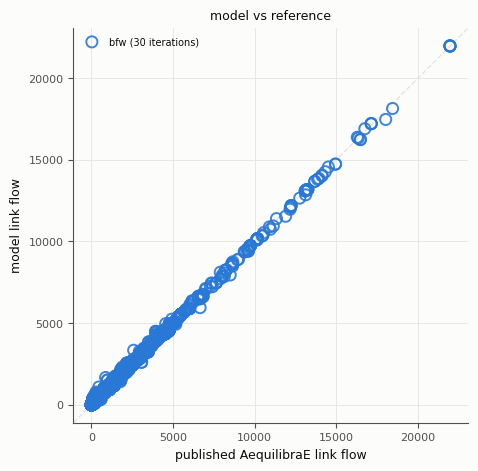

In [6]:
display(viz.plot_flow_scatter(
    ("published AequilibraE", honolulu.reference.link_flows),
    {"bfw (30 iterations)": v_bfw},
))

## Takeaways & pointers

- **Disclosed, not hidden.** The wrong-centroid defect travels in the
  scenario's own `reference.note`, not only in the ADR — a benchmark that
  ships a known defect says so in the artifact itself.
- **A provenance check, not an oracle.** The published flows' own relative
  gap is ~1e-3; what this notebook certifies is conservation (exact) and
  cross-implementation correlation (>0.99) — never a best-known-flow claim.
- **The cross-domain axis is real cities, not just a bigger TNTP net.** 17 of
  20 cities ship; 3 are excluded and NAMED (Washington, Pittsburgh, Phoenix) —
  further evidence of the same wrong-centroid defect, not swept under a rug.
- **Where next.** `bo4mob` ([02-bo4mob.ipynb](02-bo4mob.ipynb)) for a second,
  very different data family (no BPR network, no true OD — an engine-liveness
  story instead); the full 20-city audit and every measured anchor in
  [docs/design/adr-033-xu2024-dataset.md](../../docs/design/adr-033-xu2024-dataset.md).